In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [11]:
df = pd.read_csv('../datasets/Algerian_forest_fires_cleaned_dataset.csv')

In [12]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [13]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [14]:
## drop month , day and Year
df.drop(['day','month','year'] , axis = 1 , inplace = True)

In [15]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [16]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [17]:
# Encoding
df['Classes'] = np.where(df['Classes'].str.contains('not fire') , 0,1)

In [18]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [19]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [67]:
# Independent and Dependent Featuress
features = [
    'Temperature',
    'RH',
    'Ws',
    'Rain',
    'FFMC',
    'DMC',
    'ISI',
    'Classes',
    'Region'
]

X = df[features]
y = df['FWI']

In [68]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
0,29,57,18,0.0,65.7,3.4,1.3,0,0
1,29,61,13,1.3,64.4,4.1,1.0,0,0
2,26,82,22,13.1,47.1,2.5,0.3,0,0
3,25,89,13,2.5,28.6,1.3,0.0,0,0
4,27,77,16,0.0,64.8,3.0,1.2,0,0


In [69]:
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: FWI, dtype: float64

In [70]:
# Train Test Split 
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size = 0.25 , random_state = 42)

In [71]:
X_train.shape , X_test.shape

((182, 9), (61, 9))

<Axes: >

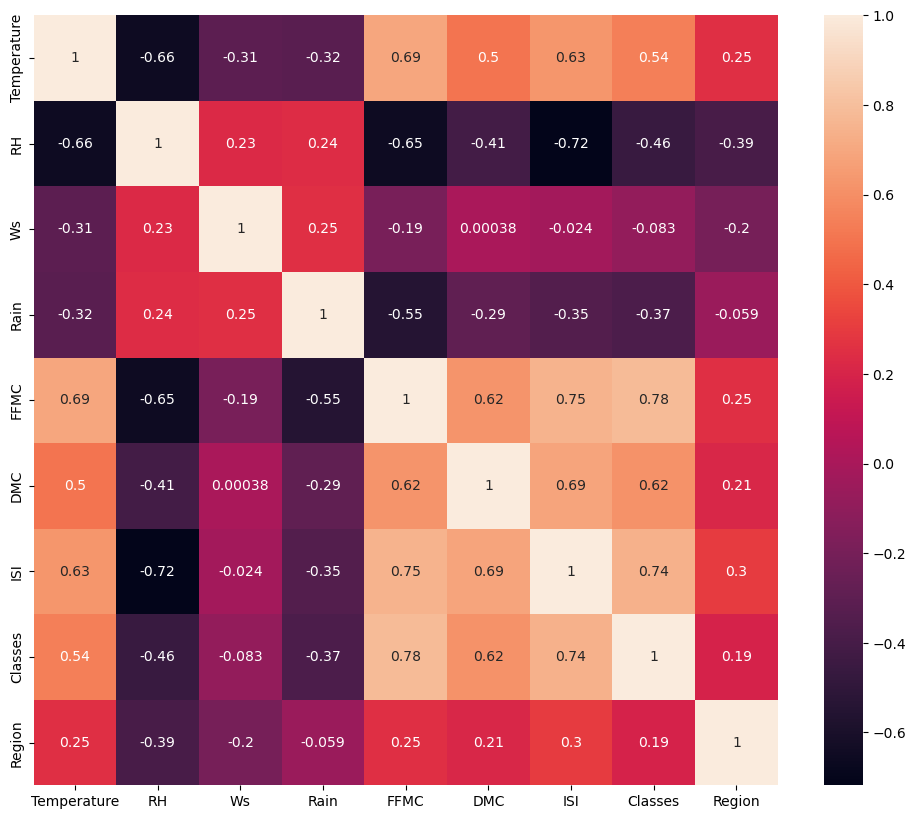

In [72]:
## Multicollinearity happens when two or more independent input features in a machine learning model are highly correlated with each other.
# Check the Multicollinearity
plt.figure(figsize =(12,10))
corr =X_train.corr()
sns.heatmap(corr,annot = True)

In [73]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.629848,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.717804,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,-0.023558,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.345707,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.750799,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.685656,0.617273,0.212582
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,1.000000,0.742977,0.296441
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.742977,1.000000,0.188837
Region,0.254549,-0.394665,-0.199969,-0.059022,0.249514,0.212582,0.296441,0.188837,1.000000


In [74]:
def correlation(dataset , threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j  in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [75]:
# Threshold set by Domain Expertise 
corr_features = correlation(X_train , 0.85)

In [76]:
corr_features 

set()

In [77]:
# Drop features when correlation is more than 0.85
X_train.drop(corr_features, axis = 1 , inplace = True)
X_test.drop(corr_features , axis = 1 , inplace = True)
X_train.shape , X_test.shape

((182, 9), (61, 9))

In [23]:
# Feature Scaling Or Standardization

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train After Scaling')

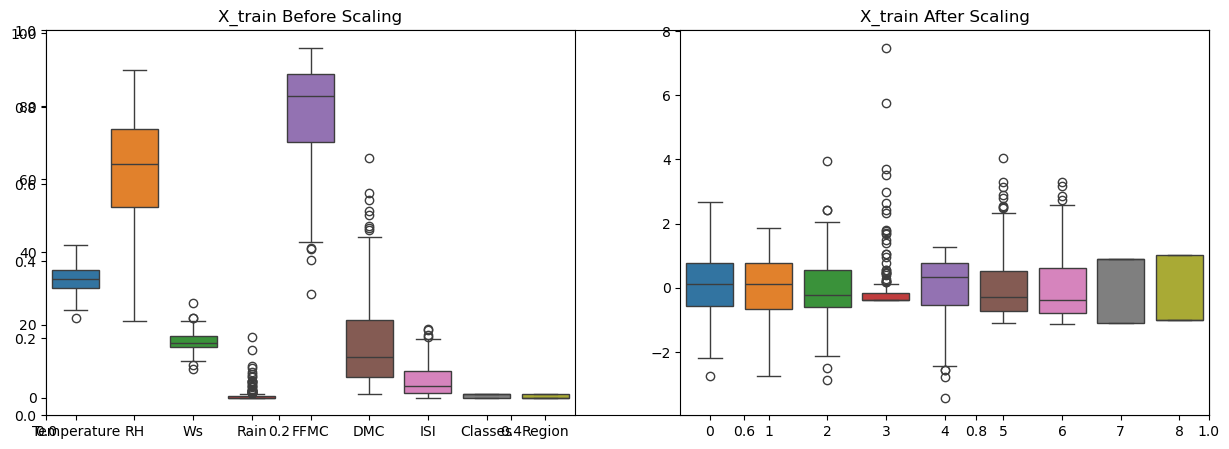

In [81]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
'''
1 (nrows): Specifies the total number of rows in the grid.
2 (ncols): Specifies the total number of columns in the grid.
1 (index): Specifies the active position for the current plotting commands. The index is 1-based, starting at the top-left corner and increasing to the righ
'''
sns.boxplot(data = X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title('X_train After Scaling')

In [82]:
# Linear Regression Model

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled , y_train)
y_pred = linreg.predict(X_test_scaled)

In [84]:
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
score = r2_score(y_test , y_pred)

print(mae)
print(mse)
print(score)

0.5468236465249978
0.674276687379158
0.9847657384266951


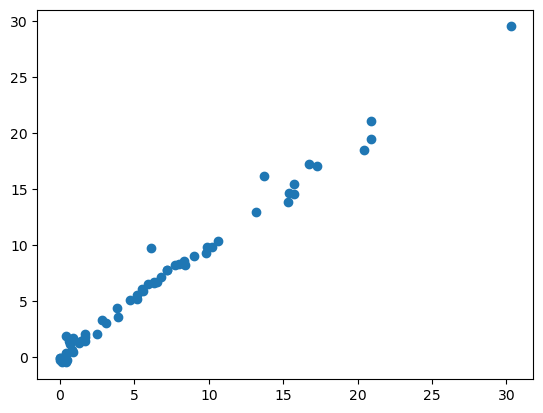

In [85]:
plt.scatter(y_test  , y_pred)

In [31]:
# Lasso Regression

MAE =  1.133175994914409
MSE =  2.2483458918974772
R2_score = 0.9492020263112388


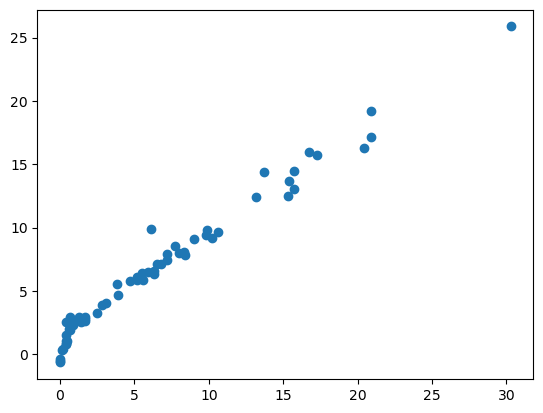

In [87]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score
lasso = Lasso()
lasso.fit(X_train_scaled , y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("MAE = ", mae)
print("MSE = ",mse)
print("R2_score =",score)
plt.scatter(y_test,y_pred)

In [88]:
# Cross Validation Lasso
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled , y_train)
print(lassocv.alpha_)

0.05725391318234408


In [42]:
print(lassocv.alphas_)

[7.05853002 6.58280872 6.13914944 5.72539132 5.33951911 4.97965339
 4.64404142 4.33104857 4.03915039 3.76692517 3.51304702 3.27627941
 3.05546914 2.84954075 2.65749124 2.47838523 2.31135036 2.15557308
 2.01029467 1.87480753 1.74845178 1.63061198 1.52071419 1.41822315
 1.32263965 1.23349817 1.15036452 1.0728338  1.00052839 0.93309613
 0.87020857 0.81155943 0.75686304 0.705853   0.65828087 0.61391494
 0.57253913 0.53395191 0.49796534 0.46440414 0.43310486 0.40391504
 0.37669252 0.3513047  0.32762794 0.30554691 0.28495408 0.26574912
 0.24783852 0.23113504 0.21555731 0.20102947 0.18748075 0.17484518
 0.1630612  0.15207142 0.14182231 0.13226397 0.12334982 0.11503645
 0.10728338 0.10005284 0.09330961 0.08702086 0.08115594 0.0756863
 0.0705853  0.06582809 0.06139149 0.05725391 0.05339519 0.04979653
 0.04644041 0.04331049 0.0403915  0.03766925 0.03513047 0.03276279
 0.03055469 0.02849541 0.02657491 0.02478385 0.0231135  0.02155573
 0.02010295 0.01874808 0.01748452 0.01630612 0.01520714 0.01418

In [89]:
print(lassocv.mse_path_)

[[53.64536329 65.39074075 54.89628985 77.90299066 39.38236846]
 [46.99139716 59.81506814 49.29840831 75.6645852  35.31758355]
 [41.14908917 53.9178721  42.49594889 68.35708298 31.76996123]
 [36.05788169 48.41773965 36.66879347 61.92819453 28.67296816]
 [31.62067285 42.76466229 31.68391904 56.26841266 24.93183295]
 [27.75285367 37.81922812 27.42599138 51.28216115 21.56888645]
 [24.3807738  33.49107651 23.7950306  45.25481907 18.66094162]
 [21.44052804 29.70161639 20.70460191 39.90418045 16.14837778]
 [18.876308   26.38208059 18.07969934 35.23429953 13.97821475]
 [16.63960395 23.47341883 15.85530749 31.15712074 12.10483403]
 [14.68819307 20.92329068 13.97555108 27.59649208 10.48862803]
 [12.98525144 18.68636627 12.39173305 24.48611006  9.09521221]
 [11.49893734 16.72312788 11.06186319 21.7677198   7.89445038]
 [10.2013182  14.9991189   9.94965275 19.39216316  6.86106557]
 [ 9.06814642 13.48429046  9.02375611 17.31505177  5.9722389 ]
 [ 8.0783105  12.15220147  8.25686268 15.49825178  5.20

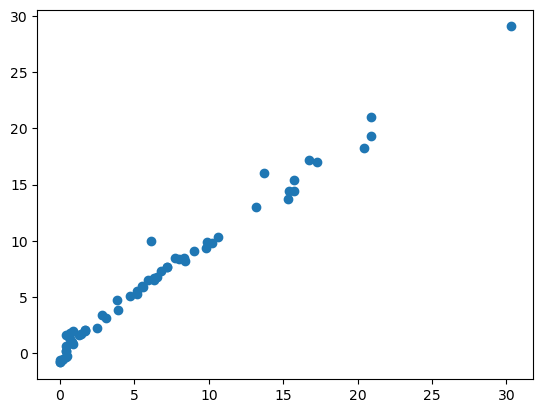

In [36]:
y_pred  = lassocv.predict(X_test_scaled)
plt.scatter(y_test , y_pred)
mae = mean_absolute_error(y_test ,y_pred)
mse = mean_squared_error(y_test ,y_pred)
score = r2_score(y_test , y_pred)

MAE =  1.133175994914409
MSE =  2.2483458918974772
R2_score = 0.9492020263112388


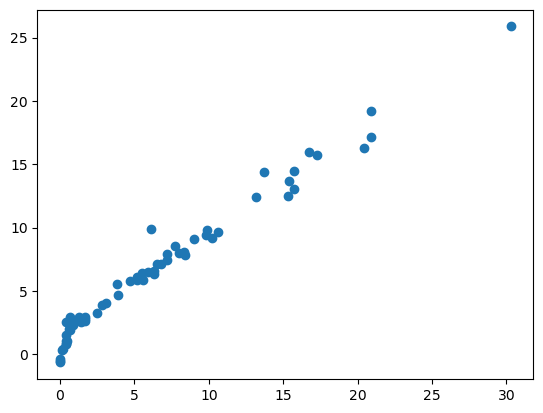

In [90]:
print("MAE = ", mae)
print("MSE = ",mse)
print("R2_score =",score)
plt.scatter(y_test,y_pred)

In [91]:
# Ridge Regression Model 

In [92]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled , y_train)
y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("MAE =" ,mae)
print("R2_score = ",score)

MAE = 0.5642305340105715
R2_score =  0.9842993364555512


In [93]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv = 5)
ridgecv.fit(X_train_scaled , y_train)


RidgeCV(cv=5)

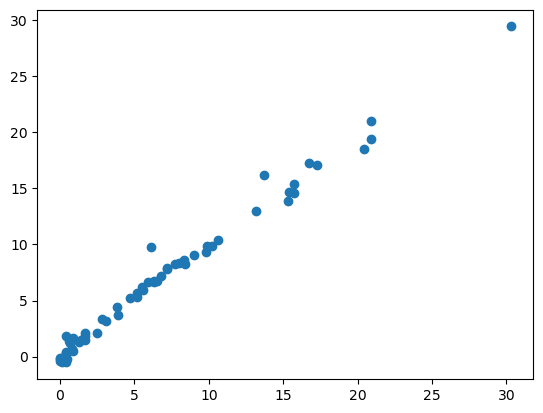

In [94]:
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
plt.scatter(y_test , y_pred)

In [95]:
print("MAE :",mae)
print("R2_score ",score)

MAE : 0.5642305340105715
R2_score  0.9842993364555512


MAE = 1.8822353634896005
R2_Score = 0.8753460589519703


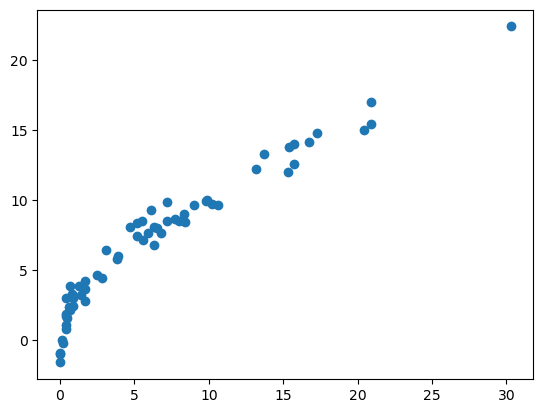

In [96]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic = ElasticNet()
elastic.fit(X_train_scaled , y_train)
y_pred =  elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test , y_pred)
print("MAE =" ,mae)
print("R2_Score =",score)
plt.scatter(y_test , y_pred)

MAE = 0.6575946731430898
R2_Score = 0.9814217587854941


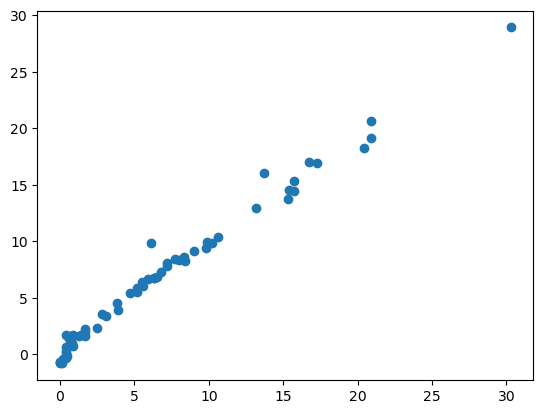

In [97]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic = ElasticNetCV(cv = 5)
elastic.fit(X_train_scaled , y_train)
y_pred =  elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test , y_pred)
print("MAE =" ,mae)
print("R2_Score =",score)
plt.scatter(y_test , y_pred)

In [98]:
# Pickle the machine Learning Models , preprocessing model standardScaler

In [99]:
scaler

StandardScaler()

In [100]:
ridge

Ridge()

In [107]:
import pickle
pickle.dump(scaler ,open('../models/scaler.pkl','wb'))
pickle.dump(ridge,open('../models/regression.pkl','wb'))


In [108]:
'''
pickle converts a Python object into a format that can be stored on your disk, and later reconstructs that object back into Python.
'''
print("Model features:", ridge.n_features_in_)
print("Scaler features:", scaler.n_features_in_)
print("Feature names:", getattr(scaler, "feature_names_in_", "Not available"))

Model features: 9
Scaler features: 9
Feature names: ['Temperature' 'RH' 'Ws' 'Rain' 'FFMC' 'DMC' 'ISI' 'Classes' 'Region']


In [109]:
import pickle

model = pickle.load(open('../models/regression.pkl', 'rb'))
scaler = pickle.load(open('../models/scaler.pkl', 'rb'))

print("Model features:", model.n_features_in_)
print("Scaler features:", scaler.n_features_in_)

print("Scaler feature names:", scaler.feature_names_in_)

Model features: 9
Scaler features: 9
Scaler feature names: ['Temperature' 'RH' 'Ws' 'Rain' 'FFMC' 'DMC' 'ISI' 'Classes' 'Region']
